In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState


In [2]:
from langchain.chat_models import init_chat_model

In [3]:
model_id="gemini-2.5-flash-preview-05-20"
llm = init_chat_model(model=model_id,  model_provider="google_vertexai")

In [4]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = llm.invoke(state['messages'])
    return state

In [5]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("llm", call_model)
graph_builder.add_edge(START, "llm")
graph_builder.add_edge("llm", END)
graph = graph_builder.compile()

In [6]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display

def draw_graph(graph: CompiledStateGraph):
    display(Image(graph.get_graph().draw_mermaid_png()))

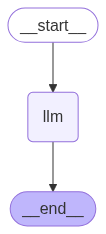

In [7]:
draw_graph(graph)


In [8]:
from langchain_core.messages import SystemMessage, HumanMessage
messages = [
    SystemMessage("You are an helpful assistant"),
    HumanMessage("I would like to know about democracy")

]
result = graph.invoke({"messages": messages})

In [9]:
result['messages']


[SystemMessage(content='You are an helpful assistant', additional_kwargs={}, response_metadata={}, id='655d1c11-8dcd-4bd1-ba81-090bf0437be3'),
 HumanMessage(content='I would like to know about democracy', additional_kwargs={}, response_metadata={}, id='97e728bc-8047-4dc9-85fe-f9e4fa1e81b8'),
 AIMessage(content='Democracy is a fascinating and incredibly important concept in political science and governance. At its core, the word "democracy" comes from the Greek words "demos" (people) and "kratos" (power or rule), meaning **"rule by the people."**\n\nHere\'s a breakdown of its key aspects:\n\n---\n\n### What is Democracy?\n\nIn essence, democracy is a system of government where the **people hold the ultimate power.** This power is typically exercised either directly by the people themselves or through elected representatives who act on their behalf. The fundamental idea is that the government derives its legitimacy from the consent of the governed.\n\n---\n\n### Key Principles and Pillar

In [10]:
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an helpful assistant
================================ Human Message =================================

I would like to know about democracy
================================== Ai Message ==================================

Democracy is a fascinating and incredibly important concept in political science and governance. At its core, the word "democracy" comes from the Greek words "demos" (people) and "kratos" (power or rule), meaning **"rule by the people."**

Here's a breakdown of its key aspects:

---

### What is Democracy?

In essence, democracy is a system of government where the **people hold the ultimate power.** This power is typically exercised either directly by the people themselves or through elected representatives who act on their behalf. The fundamental idea is that the government derives its legitimacy from the consent of the governed.

---

### Key Principles and Pillars of Democracy